In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Deep Evidential Regression

This notebook is based on [_Deep Evidential Regression_ by Amini et al.](https://arxiv.org/pdf/1910.02600) and [Evidential Deep Learning in PyTorch](https://github.com/teddykoker/evidential-learning-pytorch).

Let's assume we have a dataset, $\mathcal{D}$, with $N$ observations, $\mathcal{D} = \{ \mathbf{x}_i, y_i \}_{i=1}^N $.

Let's create a toy dataset


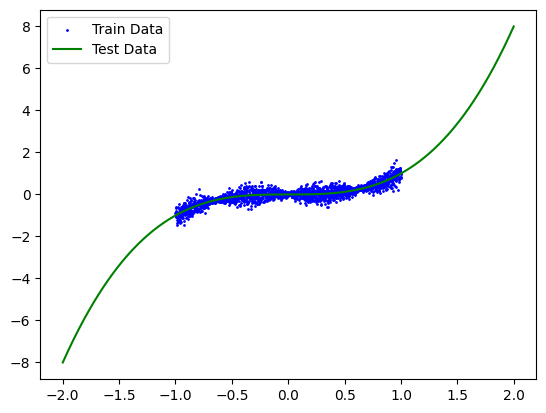

In [2]:
N = 2000
TRAIN_BOUNDS = (-1, 1)
TEST_BOUNDS = (-2, 2)

x_train = np.linspace(TRAIN_BOUNDS[0], TRAIN_BOUNDS[1], N).reshape(-1, 1)
# Heteroscedastic noise: std depends on x
noise_std = (np.abs(np.sin(x_train * 5))) * 0.2 + 0.05
y_train = x_train**3 + np.random.normal(0, noise_std, size=(N, 1))

x_test = np.linspace(TEST_BOUNDS[0], TEST_BOUNDS[1], N).reshape(-1, 1)
y_test = x_test**3

plt.figure()
plt.scatter(x_train, y_train, label="Train Data", s=1, color="blue")
plt.plot(x_test, y_test, label="Test Data", color="green")
plt.legend()

In [3]:
# Prepare data for PyTorch
train_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(x_train), torch.FloatTensor(y_train)
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)


def get_infinite_loader(loader):
    while True:
        for batch in loader:
            yield batch


train_loader_inf = iter(get_infinite_loader(train_loader))

test_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(x_test), torch.FloatTensor(y_test)
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False)

**Deep Evidential Regression** aims to _directly learn both the aleatoric uncertainty present in the data as well as the model's underlying epistemic uncertainty_.

For **Deep Evidential Regression**, we assume

$$
y_i \sim \mathcal{N}(\mu_i, \sigma_i^2) \\
\mu_i \sim \mathcal{N}(\gamma, \sigma_i^2 * v^{-1}) \\
\sigma_i^2 \sim \Gamma^{-1}(\alpha, \beta)
$$

meaning we treat $\mu$ and $\sigma^2$ as unknown and place prior distributions on them.
The goal is to estimate the posterior distribution $p(\mu, \sigma^2 | \mathcal{D})$. Due to conjugacy, this distribution will be a **Normal-Inverse-Gamma** distribution.

We can compute the prediction, aleatoric and epistemic uncertainty from this posterior distribution:
1. Prediction
$$
\mathbb{E}[\mu] = \gamma
$$

2. Aleatoric uncertainty
$$
\mathbb{E}[\sigma^2] = \frac{\beta}{\alpha - 1}
$$

3. Epistemic uncertainty
$$
\mathbb{V}[\mu] = \frac{\beta}{v(\alpha - 1)}
$$

The question remains how to find the parameters $\mathbf{m} = \gamma, v, \alpha, \beta$.
Simply put, we use a Neural Network to infer $m$ given an input $\mathbf{x}$.

### Neural Network Architecture

The model is a simple fully-connected network that outputs four parameters for each input:
- **$\gamma$**: The predicted mean
- **$v$**: The precision of the prior over $\mu$
- **$\alpha$**: The shape parameter of the inverse gamma distribution
- **$\beta$**: The scale parameter of the inverse gamma distribution

These parameters fully define the Normal-Inverse-Gamma posterior distribution. We apply softplus activation to ensure $v$, $\alpha$, and $\beta$ are positive, and add 1 to $\alpha$ to ensure $\alpha > 1$ (required for the uncertainty computations).

In [4]:
class RegressionMLP(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, depth=4):
        super(RegressionMLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            *[
                nn.Sequential(nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
                for _ in range(depth - 1)
            ],
            nn.ReLU(),
            nn.Linear(hidden_dim, 4),
        )

    def forward(self, x):
        x = self.layers(x)

        gamma, logv, logalpha, logbeta = torch.split(x, 1, dim=-1)
        v = F.softplus(logv)
        # alpha = F.softplus(logalpha) + 1
        alpha = v + 1
        beta = F.softplus(logbeta)

        # clamp v, alpha, beta to prevent numerical issues
        # alpha = torch.clamp(alpha, min=1 + 1e-8)
        # beta = torch.clamp(beta, min=1e-8)

        return torch.cat([gamma, v, alpha, beta], dim=-1)

In [31]:
def compute_prediction(gamma, _v, _alpha, _beta):
    return gamma


def compute_aleatoric_uncertainty(_gamma, _v, alpha, beta):
    return np.sqrt(beta / (alpha - 1))


def compute_epistemic_uncertainty(_gamma, v, alpha, beta):
    return np.sqrt(beta / (v * (alpha - 1)))

### Loss Functions

In [13]:
def evidential_loss(gamma, v, alpha, beta, y, reg_lambda, eps=1e-6):
    y_pred = gamma
    error = y - y_pred
    var = beta / v

    data_term = torch.log(var + eps)
    residual_term = (1.0 + reg_lambda * v) * error ** 2 / var
    loss = data_term + residual_term

    return loss.mean(), (data_term.mean(), residual_term.mean())




### Training the Model on Toy Dataset


In [27]:
learning_rate = 1e-4
reg_lambda = 0.0001
num_iterations = 5_000
hidden_dim = 128
depth = 3


model = RegressionMLP(hidden_dim=hidden_dim, depth=depth)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

loss_history = []
tqdm_bar = tqdm(range(num_iterations))
for iteration in tqdm_bar:
    model.train()
    batch_x, batch_y = next(train_loader_inf)
    optimizer.zero_grad()
    outputs = model(batch_x)
    gamma, v, alpha, beta = outputs[:, 0], outputs[:, 1], outputs[:, 2], outputs[:, 3]

    
    loss, (nll_loss, reg_loss) = evidential_loss(
        gamma, v, alpha, beta, batch_y[:, 0], reg_lambda=reg_lambda
    )

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    # Logging
    loss_history.append((loss.item(), nll_loss.item(), reg_loss.item()))
    running_losses = np.array(loss_history[-100:])
    tqdm_bar.set_postfix(
        loss=running_losses[:, 0].mean(),
        nll_loss=running_losses[:, 1].mean(),
        reg_loss=running_losses[:, 2].mean(),
        lr=optimizer.param_groups[0]["lr"],
    )

100%|██████████| 5000/5000 [01:25<00:00, 58.41it/s, loss=-2.39, lr=0.0001, nll_loss=-3.4, reg_loss=1.01]    


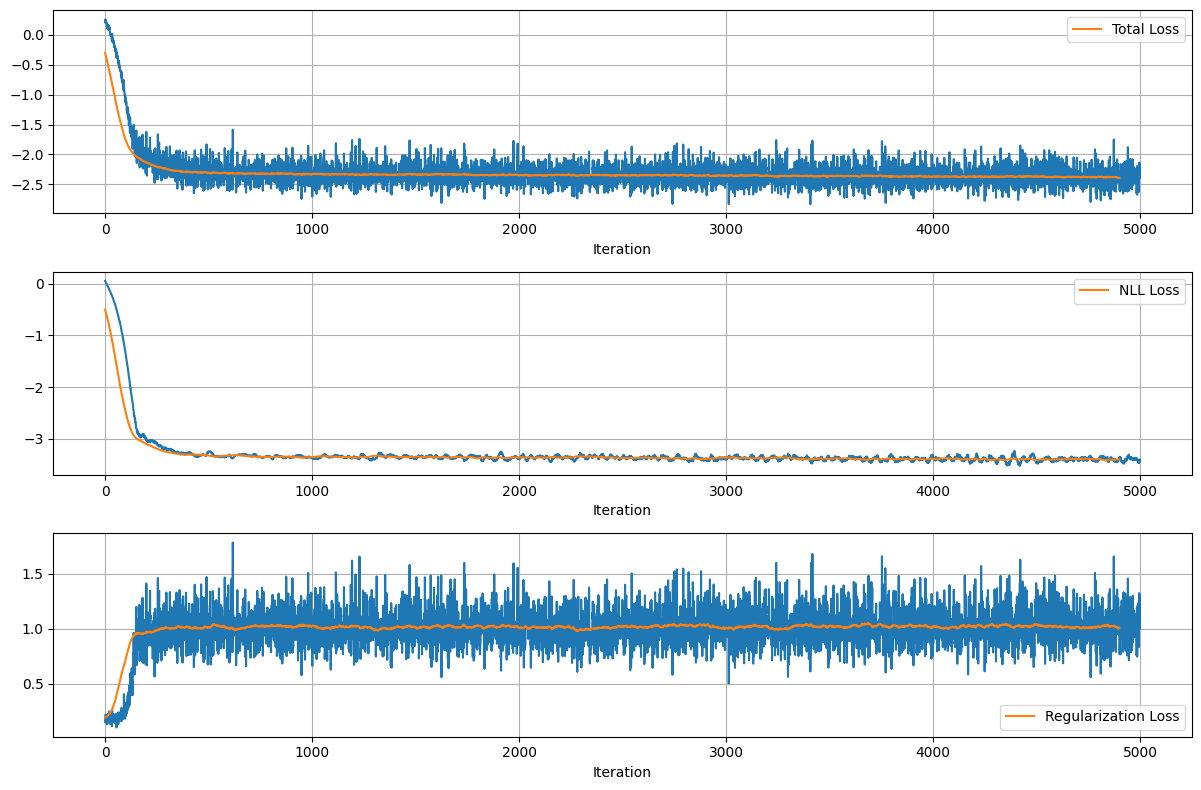

In [28]:
# convert history list to running average for smoother plots
loss_history = np.array(loss_history)
window_size = 100
loss_history_smooth = np.array(
    [
        np.convolve(
            loss_history[:, i], np.ones(window_size) / window_size, mode="valid"
        )
        for i in range(loss_history.shape[1])
    ]
).T

# visualize training losses
fig, axs = plt.subplots(3, 1, figsize=(12, 8))
for i in range(3):
    axs[i].plot(loss_history[:, i])

axs[0].plot(loss_history_smooth[:, 0], label="Total Loss")
axs[1].plot(loss_history_smooth[:, 1], label="NLL Loss")
axs[2].plot(loss_history_smooth[:, 2], label="Regularization Loss")
for i, ax in enumerate(axs):
    ax.grid()
    ax.legend()
    ax.set_xlabel("Iteration")

fig.tight_layout()

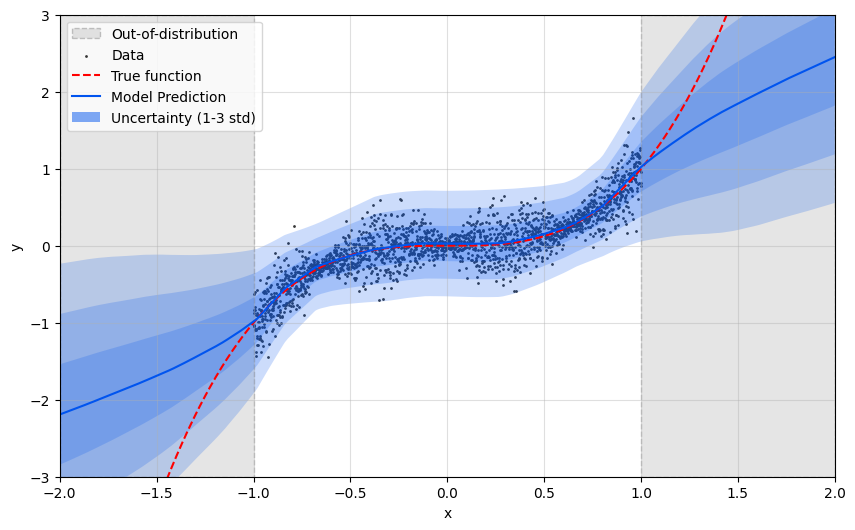

In [34]:
model.eval()
outputs = model(torch.FloatTensor(x_test)).detach().cpu().numpy()
gamma, v, alpha, beta = outputs[:, 0], outputs[:, 1], outputs[:, 2], outputs[:, 3]

y_pred = compute_prediction(gamma, v, alpha, beta)
uncertainty_epistemic = compute_epistemic_uncertainty(gamma, v, alpha, beta)
uncertainty_aleatoric = compute_aleatoric_uncertainty(gamma, v, alpha, beta)
uncertainty_total = np.sqrt(uncertainty_aleatoric**2 + uncertainty_epistemic**2)


fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(alpha=0.4)
ax.axvspan(
    TEST_BOUNDS[0],
    TRAIN_BOUNDS[0],
    edgecolor="black",
    linestyle="--",
    facecolor="gray",
    alpha=0.2,
    label="Out-of-distribution",
)
ax.axvspan(
    TRAIN_BOUNDS[1],
    TEST_BOUNDS[1],
    edgecolor="black",
    linestyle="--",
    facecolor="gray",
    alpha=0.2,
)
ax.scatter(x_train, y_train, s=1, c="#393939", label="Data")
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.plot(x_test, y_test, c="red", linestyle="--", label="True function")

ax.plot(x_test, y_pred, c="#0054ef", label="Model Prediction")
for k in np.linspace(1, 3, 3):
    ax.fill_between(
        x_test[:, 0],
        y_pred - k * uncertainty_total,
        y_pred + k * uncertainty_total,
        color="#0054ef",
        edgecolor=None,
        alpha=0.2,
    )
ax.set_ylim(-3, 3)
ax.set_xlim(TEST_BOUNDS[0], TEST_BOUNDS[1])

# add legend entry for uncertainty
unc_patch = plt.Rectangle(
    (0, 0), 0.01, 0.01, fc="#0054ef", alpha=0.5, label="Uncertainty (1-3 std)"
)
ax.add_artist(unc_patch)

ax.legend(loc="upper left")

### Uncertainty Decomposition

The plot below shows how the two types of uncertainty behave differently:

- **Aleatoric uncertainty** (green) 
- **Epistemic uncertainty** (orange) 

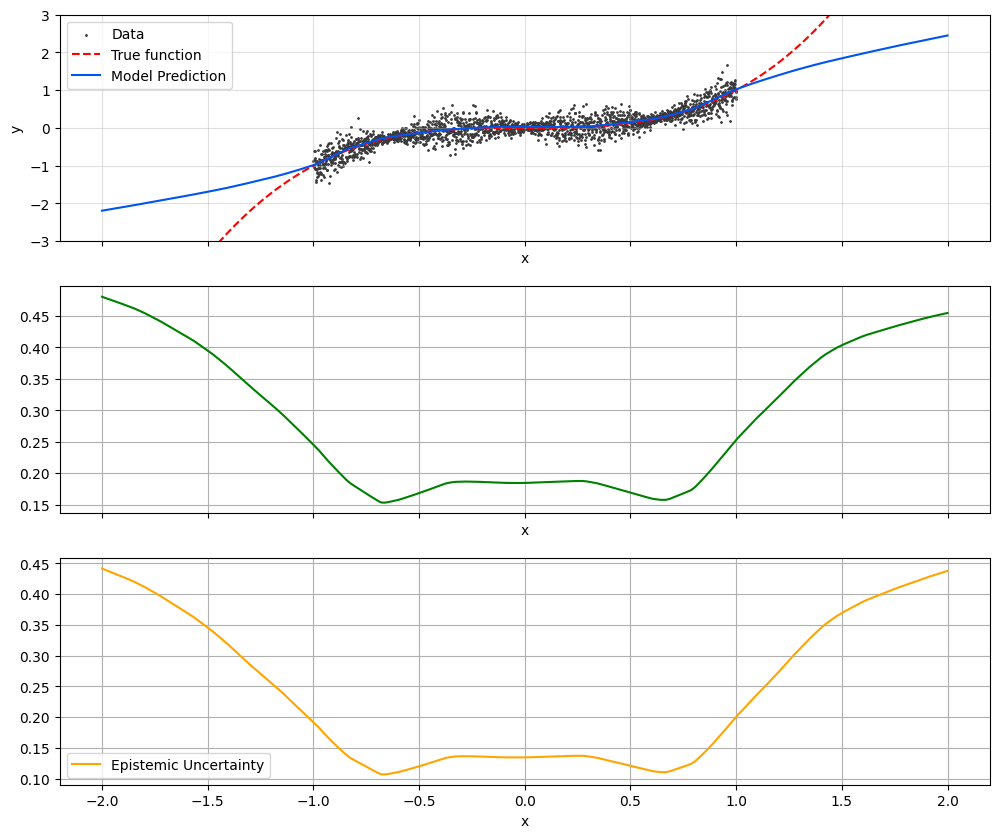

In [33]:
fig, axs = plt.subplots(nrows=3, figsize=(12, 10), sharex=True)

axs[0].grid(alpha=0.4)
axs[0].scatter(x_train, y_train, s=1, c="#393939", label="Data")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].plot(x_test[:, 0], y_test, c="red", linestyle="--", label="True function")
axs[0].set_ylim(-3, 3)
axs[0].plot(x_test[:, 0], y_pred, c="#0054ef", label="Model Prediction")
axs[0].legend()


axs[1].grid()
axs[1].plot(
    x_test[:, 0],
    uncertainty_aleatoric,
    label=r"Aleatoric Uncertainty",
    c="green",
)
axs[1].set_xlabel("x")

axs[2].grid()
axs[2].plot(
    x_test[:, 0],
    uncertainty_epistemic,
    label=r"Epistemic Uncertainty",
    c="orange",
)
axs[2].set_xlabel("x")
axs[2].legend()